In [49]:
import getdist.plots as gdplt
from cobaya import load_samples
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
plt.rc('axes', labelsize=20)
plt.rc('font', size=14)

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

## BAO + CMB priors using likelihood : ``like_DESI_CMB_all.py``

In [2]:
fake_LCDM = False

## old stuff

### all redshifts

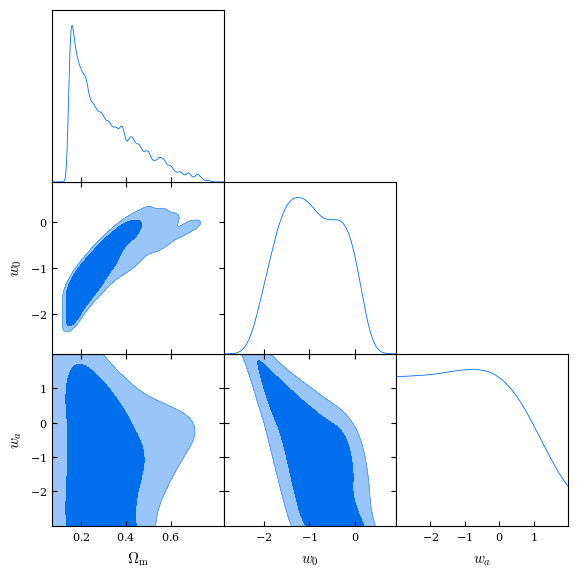

In [ ]:
path = r'C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_all_run1' # forgot to add hrdrag in that one
path = r'C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_all_run2'
if fake_LCDM:
    path = r'C:\EPFL\MA4\code\cobaya_runs\fake_data\Planck_flat_LCDM\exact\BAO+CMB_all_run1'

path = r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\DESI_data\test_DESI_CMB_lik\onlyCMB\chain'

samples = load_samples(path, to_getdist=True, skip=0.33)
varNames = ['hrdrag', 'omm', 'w', 'wa']
varNames = varNames[1:]

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(samples, varNames, filled=True)

In [26]:
cov_w_wa = samples.cov(['w', 'wa'])
print(cov_w_wa)
mean_w_wa = samples.mean(['w', 'wa'])
gauss_cnt = np.random.multivariate_normal(mean=mean_w_wa, cov=cov_w_wa, size=10000)

from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(gauss_cnt[:, 0], gauss_cnt[:, 1])
print(f"wa = {slope:.2f} * w0 + {intercept:.2f}")

from scipy.optimize import curve_fit
def linear_model(x, a):
    return a * (x + 1)

popt, pcov = curve_fit(linear_model, gauss_cnt[:, 0], gauss_cnt[:, 1])
print(f"best fit slope (passing by LCDM) : {popt[0]:.2f}")

[[ 0.04654307 -0.13221194]
 [-0.13221194  0.39311921]]
wa = -2.84 * w0 + -2.93
best fit slope (passing by LCDM) : -2.97


### corner plot individual redshift

In [5]:
path1 = r"C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_all_run2"
if fake_LCDM:
    path1 = r'C:\EPFL\MA4\code\cobaya_runs\fake_data\Planck_flat_LCDM\exact\BAO+CMB_all_run1'
# path2 = r"C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_individual\z1_w_wa"
# path3 = r"C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_individual\z4_w_wa"
# path_indiv = [rf"C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_individual\z{z}_w_wa" for z in range(3, 8)]

names = ["hrdrag", "omm", "w", "wa"]
labels = ["BGS", "LRG1", "LRG2", "LRG3+ELG1", "ELG2", "QSO", r"Ly$\alpha$"]

for z in range(1, 8):
    path = rf"C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_individual\z{z}_w_wa"
    if fake_LCDM:
        path = rf"C:\EPFL\MA4\code\cobaya_runs\fake_data\Planck_flat_LCDM\exact\individual_z\z{z}"
#     gd_sample = [load_samples(path, to_getdist=True, skip=0.33),
#                  load_samples(path1, to_getdist=True, skip=0.33)]
#     gdplot = gdplt.get_subplot_plotter()
#     gdplot.settings.title_limit_fontsize = 14
#     gdplot.triangle_plot(gd_sample, names, filled=True, legend_labels=[labels[z-1], "All redshifts"], 
#                         title_limit=1,
#                         markers={names[2]: -1, names[3]: 0},
#                         marker_args={"lw": 1})

## individual redshifts in $w_0 - w_a$ plane

In [7]:
path_all_fid = r'C:\EPFL\MA4\code\PDM2026\cobaya_chains\DESI_DR2\fid_values\chain'
# path1_DESI = r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_all_run2'
path_all_DESI = r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_all_run2'
# path_all_BAOCMB_fid_old = r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\fake_data\Planck_flat_LCDM\exact\BAO+CMB_all_run1'
path_all_BAOCMB_fid = r'C:\EPFL\MA4\code\PDM2026\cobaya_chains\BAO_CMB\fid_centered\chain'
path_all_BAOCMB_planck_fid = r'C:\EPFL\MA4\code\PDM2026\cobaya_chains\BAO_CMB\fid_centered\Planck_fid_centered\chain'
path_all_BAOCMB_DESI = r'C:\EPFL\MA4\code\PDM2026\cobaya_chains\BAO_CMB\DESI_centered\chain'
# sample_all_fid = load_samples(path_all_fid, to_getdist=True, skip=0.33)
# sample_all_DESI = load_samples(path_all_DESI, to_getdist=True, skip=0.33)
sample_all_BAOCMB_fid = load_samples(path_all_BAOCMB_fid, to_getdist=True, skip=0.33)
# sample_all_BAOCMB_fid_old = load_samples(path_all_BAOCMB_fid_old, to_getdist=True, skip=0.33)
sample_all_BAOCMB_DESI = load_samples(path_all_BAOCMB_DESI, to_getdist=True, skip=0.33)

path_onlyCMB = r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\DESI_data\test_DESI_CMB_lik\onlyCMB\chain'
path_BAO_only = r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\DESI_data\base_w_wa\run1'

sample_onlyCMB = load_samples(path_onlyCMB, to_getdist=True, skip=0.33)
sample_onlyBAO = load_samples(path_BAO_only, to_getdist=True, skip=0.33)

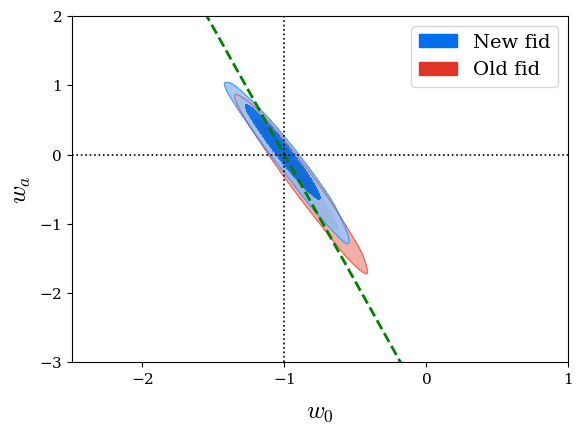

In [72]:

sample_toplot = [sample_all_BAOCMB_fid_old, sample_all_BAOCMB_fid]
# label_toplot = [labels[i], 'Combined tracers']
label_toplot = ['Old fid', 'New fid']
gdplot = gdplt.get_single_plotter()


gdplot.settings.axes_labelsize = 18
gdplot.plot_2d(sample_toplot, varNames[2], varNames[3], filled=True, contour_lws=2, alphas=[1, 0.9])

ax = plt.gca()

x_line = np.linspace(-3, 1, 10)
y_line = -3.66 * (x_line + 1)
ax.plot(x_line, y_line, ls='--', color='g', lw=2)

# x_line = np.linspace(-3, 1, 10)
# y_line = -2.97 * (x_line + 1)
# y_line = -2.84 * x_line - 2.93
# ax.plot(x_line, y_line, ls='-', color='purple')

ax.set_xlim(-2.5, 1)
ax.set_ylim(-3, 2)
ax.axhline(0, ls=':', color='k', lw=1.2)
ax.axvline(-1, ls=':', color='k', lw=1.2)

colors = gdplot.settings.solid_colors

h1 = mpatches.Patch(color=colors[0], label=label_toplot[1])
h2 = mpatches.Patch(color=colors[1], label=label_toplot[0])
# h3 = mlines.Line2D([], [], color='g', ls='--', label='Mirage line')
# h4 = mlines.Line2D([], [], color='purple', ls=':', label='Best fit line \n' + r'(passing by $\Lambda \mathrm{CDM}$)')
# h4 = mlines.Line2D([], [], color='purple', ls='-', label='DESI all z\ndegeneracy line')
ax.legend(handles=[h1, h2], loc='upper right')


# if Save_fig: 
#     path_to_fig = r'C:\EPFL\MA4\code\PDM2026\figures'
#     if fiducial:
#         gdplot.export(f'z{i+1}_fid.png', path_to_fig + r'\fake_data\w_wa_individual\early_CMB', dpi=300)
#     else:
#         gdplot.export(f'earlyCMB_z{i+1}.png', path_to_fig + r'\DESI_data\w_wa_individual\early_CMB', dpi=300)

### DESI centered

In [3]:
varNames = ['hrdrag', 'omm', 'w', 'wa']

path_indiv = [rf"C:\EPFL\MA4\code\PDM2026\cobaya_chains\individual_z_BAOCMB\DESI_centered\z{z}\chain" for z in range(1, 8)]

gd_sample = [load_samples(path, to_getdist=True, skip=0.33) for path in path_indiv] 

labels = ["BGS", "LRG1", "LRG2", "LRG3+ELG1", "ELG2", "QSO", r"Ly$\alpha$"]
# order = [5, 3, 4, 6, 2, 0, 1]
order = [3, 5, 6, 4, 2, 0, 1]

contour_colors = [
    "yellowgreen",  # BGS
    "orangered",  # LRG1
    "firebrick",  # LRG2
    "slateblue",  # LRG3+ELG1
    "steelblue",  # ELG2
    "seagreen",  # QSO
    "purple",  # Lya
]

In [4]:
# Get effective sample size for all samples
eff_size = [sample.getEffectiveSamples() for sample in gd_sample]   
print(f"Effective Sample Size: {', '.join(str(round(eff_size[i])) for i in range(len(gd_sample)))}")

Effective Sample Size: 1517, 1981, 1682, 2049, 1970, 686, 1282


In [12]:
save_fig = False
mirage_line = False

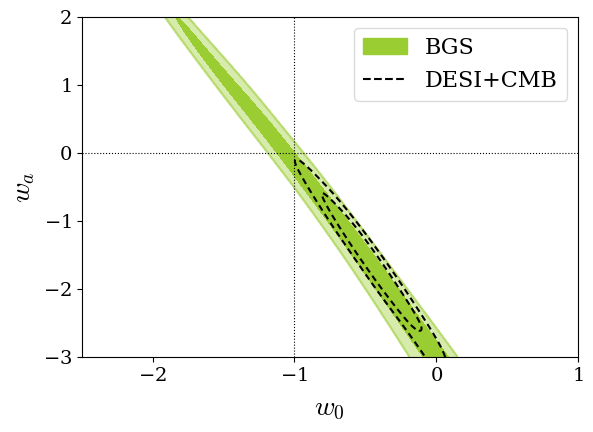

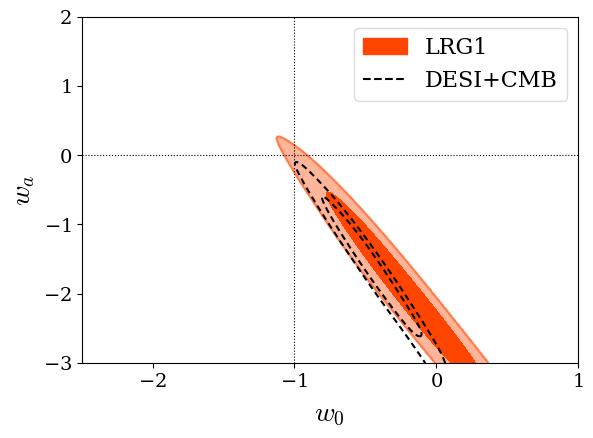

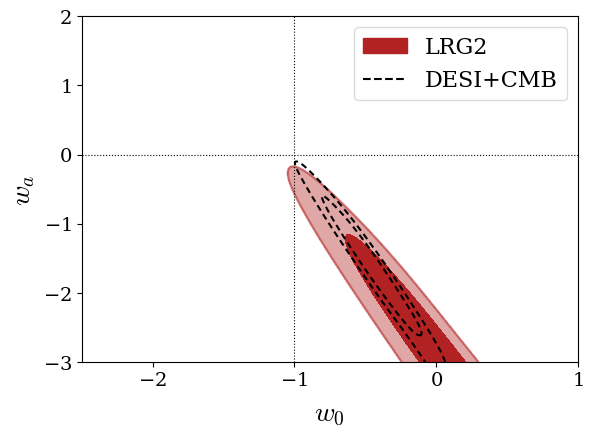

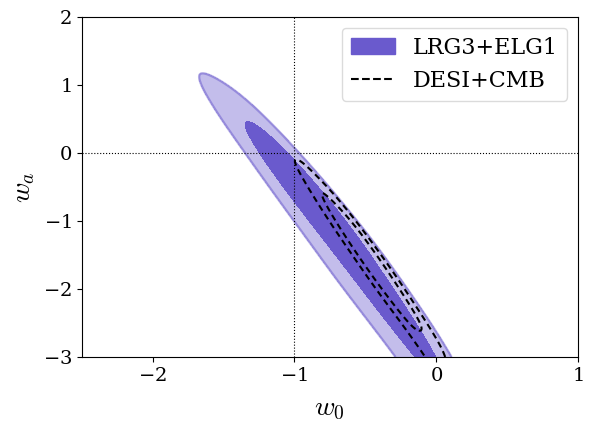

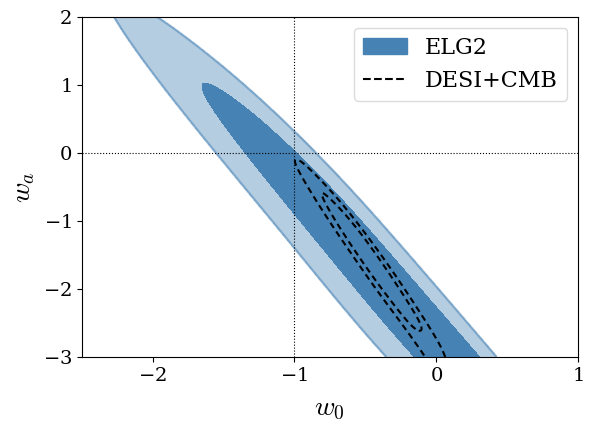

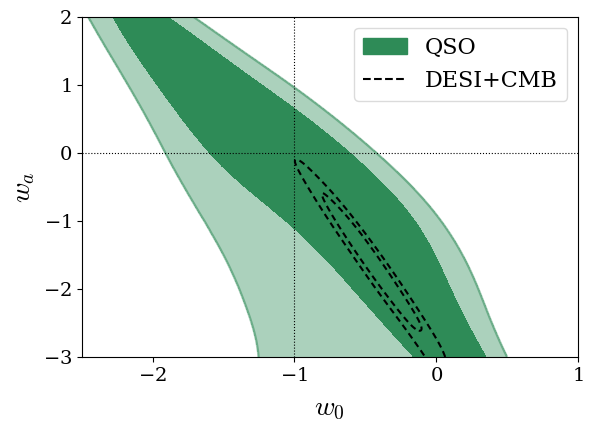

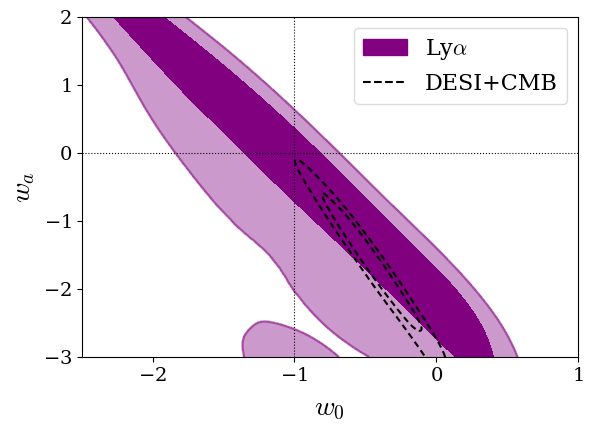

In [13]:
# for i in range(4):
for i in range(len(gd_sample)):
    sample_toplot = [gd_sample[i], sample_all_BAOCMB_DESI]
    label_toplot = [labels[i], 'DESI+CMB']
    gdplot = gdplt.get_single_plotter()

    colors = [contour_colors[i], 'black']
    line_args = [{'color': colors[0], 'lw': 1.0}, {'color': colors[1], 'lw': 1.5, 'ls':'--'}]

    gdplot.settings.axes_labelsize = 18
    gdplot.plot_2d(sample_toplot, varNames[2], varNames[3], colors=colors, filled=[True, False], line_args=line_args, alphas=[1, 1])

    ax = gdplot.get_axes()

    if mirage_line:    
        x_line = np.linspace(-3, 1, 10)
        y_line = -3.66 * (x_line + 1)
        ax.plot(x_line, y_line, ls='--', color='g', lw=2)

    ax.set_xlim(-2.5, 1)
    ax.set_ylim(-3, 2)
        
    ax.axhline(0,  color='k', ls=':', lw=0.8)
    ax.axvline(-1, color='k', ls=':', lw=0.8)

    # colors = gdplot.settings.solid_colors

    handles = []

    handles.append(mpatches.Patch(color=contour_colors[i], label=label_toplot[0]))
    # handles.append(mpatches.Patch(color='black', label=label_toplot[1]))
    handles.append(mlines.Line2D([], [], color='black', ls='--', label=label_toplot[1]))
    if mirage_line:
        handles.append(mlines.Line2D([], [], color='g', ls='--', label='Mirage line'))

    ax.legend(handles=handles, fontsize=16, framealpha=0.7, loc='upper right')
    ax.set_xlabel(r"$w_0$", fontsize=20)
    ax.set_ylabel(r"$w_a$", fontsize=20)
    ax.tick_params(axis='both', labelsize=14)

    if save_fig: 
        path_to_fig = r'C:\EPFL\MA4\code\PDM2026\figures'
        gdplot.export(f'z{i+1}_fid.pdf', path_to_fig + r'\fake_data\w_wa_individual\early_CMB', dpi=300)


### Fiducial centered

In [20]:
varNames = ['hrdrag', 'omm', 'w', 'wa']

path_indiv = [rf"C:\EPFL\MA4\code\PDM2026\cobaya_chains\individual_z_BAOCMB\fid_centered\z{z}\chain" for z in range(1, 8)]

gd_sample = [load_samples(path, to_getdist=True, skip=0.33) for path in path_indiv] 

labels = ["BGS", "LRG1", "LRG2", "LRG3+ELG1", "ELG2", "QSO", r"Ly$\alpha$"]
# order = [5, 3, 4, 6, 2, 0, 1]
order = [3, 5, 6, 4, 2, 0, 1]

contour_colors = [
    "yellowgreen",  # BGS
    "orangered",  # LRG1
    "firebrick",  # LRG2
    "slateblue",  # LRG3+ELG1
    "steelblue",  # ELG2
    "seagreen",  # QSO
    "purple",  # Lya
]

In [80]:
def get_slope_pivot_z(sample):
    cov_w_wa = sample.cov(['w', 'wa'])
    covar = cov_w_wa[0, 1]
    var_wa = cov_w_wa[1, 1]

    eigvals, eigvecs = np.linalg.eigh(cov_w_wa)
    major_axis = eigvecs[:, np.argmax(eigvals)]
    slope = major_axis[1] / major_axis[0]
    slope_alt = 1/ (covar / var_wa)
    
    ap = 1+1/slope
    ap_alt = 1+1/slope_alt
    zp = 1/ap -1
    zp_alt = 1/ap_alt -1
    return slope, slope_alt, zp, zp_alt

In [81]:
slopes = []
slopes_alt = []
zp = []
zp_alt = []
for sample in gd_sample:
    slope, slope_alt, z, z_alt = get_slope_pivot_z(sample)
    slopes.append(slope)
    slopes_alt.append(slope_alt)
    zp.append(z)
    zp_alt.append(z_alt)

In [82]:
slopes

[np.float64(-2.6859222435541352),
 np.float64(-2.3966565530245654),
 np.float64(-2.358050510644208),
 np.float64(-2.505001295217703),
 np.float64(-2.3260532807271197),
 np.float64(-2.5174810089879425),
 np.float64(-2.144356877786107)]

In [83]:
slopes_alt

[np.float64(-2.6911216720500484),
 np.float64(-2.411010732732463),
 np.float64(-2.383078669062357),
 np.float64(-2.5314013218030187),
 np.float64(-2.3633156541721227),
 np.float64(-2.7577954225167893),
 np.float64(-2.224494747946474)]

In [84]:
zp

[np.float64(0.5931471654895986),
 np.float64(0.7159956381792105),
 np.float64(0.736349636601983),
 np.float64(0.6644512554092834),
 np.float64(0.7541175113655059),
 np.float64(0.6589868301989046),
 np.float64(0.873853270261824)]

In [85]:
zp_alt

[np.float64(0.5913235082534058),
 np.float64(0.7087118310315552),
 np.float64(0.7230246712415418),
 np.float64(0.6529966937880365),
 np.float64(0.7335058443286584),
 np.float64(0.5688944158064837),
 np.float64(0.8166633639523886)]

In [86]:
s, s_alt, zp, zp_alt = get_slope_pivot_z(sample_all_BAOCMB_DESI)

In [93]:
s_alt

np.float64(-2.957066708358563)

In [47]:
# Get effective sample size for all samples
eff_size = [sample.getEffectiveSamples() for sample in gd_sample]   
print(f"Effective Sample Size: {', '.join(str(round(eff_size[i])) for i in range(len(gd_sample)))}")

Effective Sample Size: 2009, 2176, 1829, 2070, 1813, 2412, 1695


In [ ]:
save_fig = False
mirage_line = False

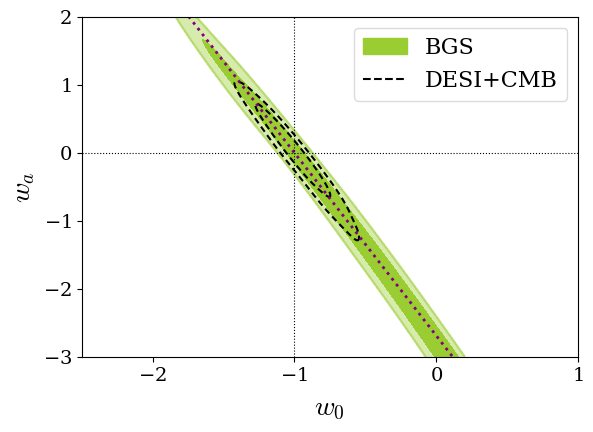

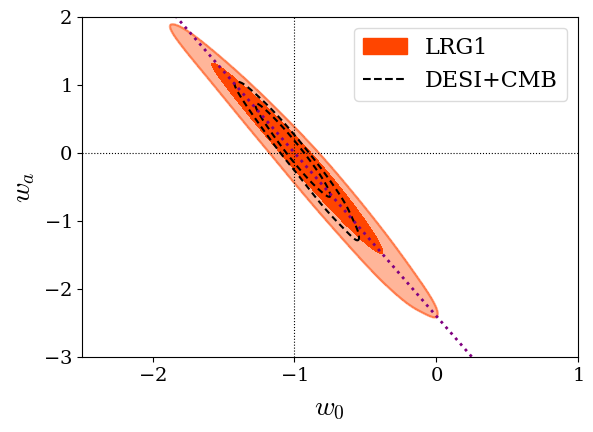

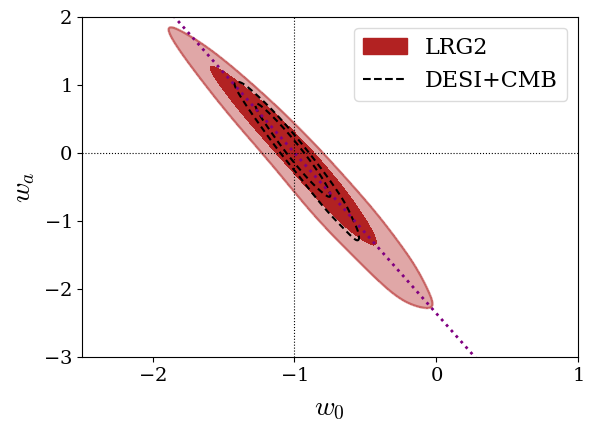

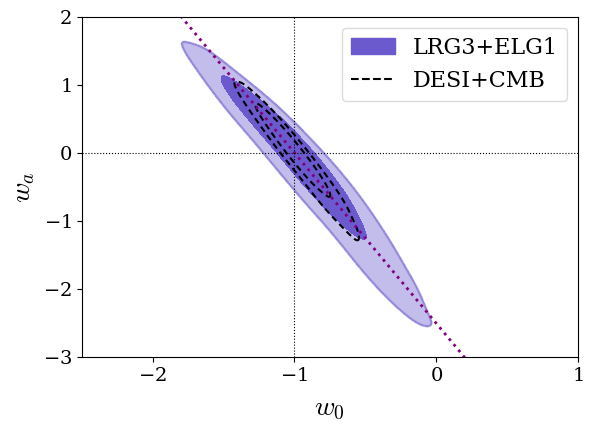

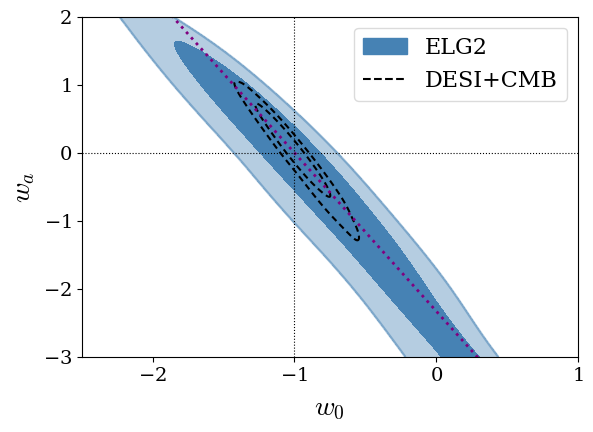

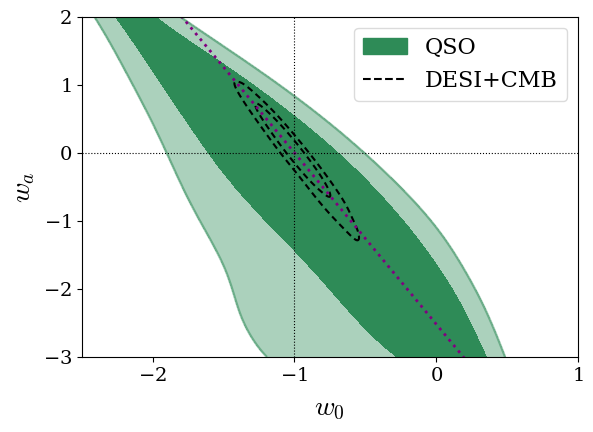

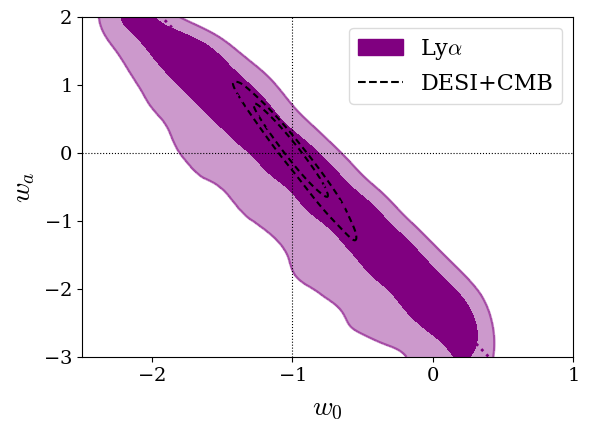

In [38]:
for i in range(len(gd_sample)):
    sample_toplot = [gd_sample[i], sample_all_BAOCMB_fid]
    label_toplot = [labels[i], 'DESI+CMB']
    gdplot = gdplt.get_single_plotter()

    colors = [contour_colors[i], 'black']
    line_args = [{'color': colors[0], 'lw': 1.0}, {'color': colors[1], 'lw': 1.5, 'ls':'--'}]

    gdplot.settings.axes_labelsize = 18
    gdplot.plot_2d(sample_toplot, varNames[2], varNames[3], colors=colors, filled=[True, False], line_args=line_args, alphas=[1, 1])

    ax = gdplot.get_axes()

    x_line = np.linspace(-3, 1, 10)

    if mirage_line:    
        y_line = -3.66 * (x_line + 1)
        ax.plot(x_line, y_line, ls='--', color='g', lw=2)

    y_line = slopes[i] * (x_line + 1)
    ax.plot(x_line, y_line, ls=':', color='purple', lw=2)

    ax.set_xlim(-2.5, 1)
    ax.set_ylim(-3, 2)
        
    ax.axhline(0,  color='k', ls=':', lw=0.8)
    ax.axvline(-1, color='k', ls=':', lw=0.8)

    # colors = gdplot.settings.solid_colors

    handles = []

    handles.append(mpatches.Patch(color=contour_colors[i], label=label_toplot[0]))
    # handles.append(mpatches.Patch(color='black', label=label_toplot[1]))
    handles.append(mlines.Line2D([], [], color='black', ls='--', label=label_toplot[1]))
    if mirage_line:
        handles.append(mlines.Line2D([], [], color='g', ls='--', label='Mirage line'))

    ax.legend(handles=handles, fontsize=16, framealpha=0.7, loc='upper right')
    ax.set_xlabel(r"$w_0$", fontsize=20)
    ax.set_ylabel(r"$w_a$", fontsize=20)
    ax.tick_params(axis='both', labelsize=14)

    if save_fig: 
        path_to_fig = r'C:\EPFL\MA4\code\PDM2026\figures'
        gdplot.export(f'z{i+1}_fid.pdf', path_to_fig + r'\fake_data\w_wa_individual\early_CMB', dpi=200)


#### plot last 2 redshift together

In [ ]:
save_double_fig = False

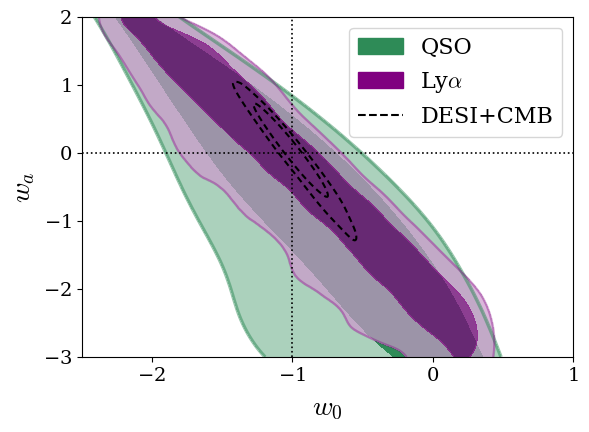

In [33]:
k, l = 6, 5

sample_toplot = [gd_sample[l], gd_sample[k], sample_all_BAOCMB_fid]
label_toplot = [labels[l], labels[k], 'DESI+CMB']
gdplot = gdplt.get_single_plotter()
gdplot.settings.axes_labelsize = 18

colors = [contour_colors[l], contour_colors[k], 'black']
line_args = [{'color': colors[0], 'lw': 1.5}, {'color': colors[1], 'lw': 1.0}, {'color': colors[2], 'lw': 1.5, 'ls':'--'}]

gdplot.plot_2d(sample_toplot, varNames[2], varNames[3], filled=[True, True, False], contour_lws=2, alphas=[1, 0.7, 1],
               line_args=line_args)

ax = plt.gca()

if mirage_line:
    x_line = np.linspace(-3, 1, 10)
    y_line = -3.66 * (x_line + 1)
    ax.plot(x_line, y_line, ls='--', color='g', lw=2)

ax.set_xlim(-2.5, 1)
ax.set_ylim(-3, 2)
ax.axhline(0, ls=':', color='k', lw=1.2)
ax.axvline(-1, ls=':', color='k', lw=1.2)

handles = []
for i in range(2):
    handles.append(mpatches.Patch(color=colors[i], label=label_toplot[i]))
handles.append(mlines.Line2D([], [], color='black', ls='--', label=label_toplot[2]))
if mirage_line:
    handles.append(mlines.Line2D([], [], color='g', ls='--', label='Mirage line'))

ax.legend(handles=handles, loc='upper right', fontsize=16)
ax.set_xlabel(r"$w_0$", fontsize=20)
ax.set_ylabel(r"$w_a$", fontsize=20)
ax.tick_params(axis='both', labelsize=14)

if save_double_fig: 
    path_to_fig = r'C:\EPFL\MA4\code\PDM2026\figures'
    gdplot.export(f'z{k+1}_z{l+1}_fid.pdf', path_to_fig + r'\fake_data\w_wa_individual\early_CMB', dpi=200)

### plot of each z alone 

In [14]:
Save_fig = True

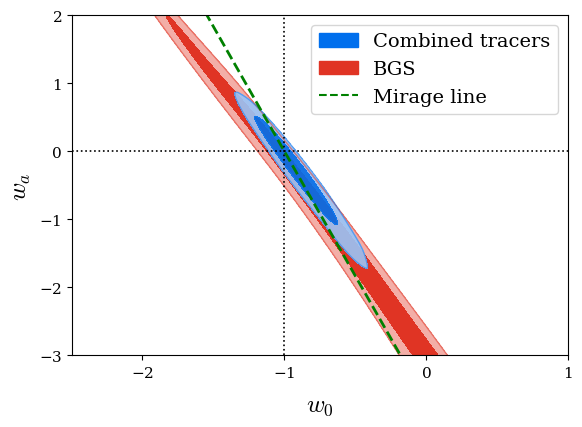

In [15]:
for i in range(1):
# for i in range(len(gd_sample)):
    sample_toplot = [gd_sample[i], tot_sample_fake if fiducial else tot_sample_DESI]
    label_toplot = [labels[i], 'Combined tracers']
    gdplot = gdplt.get_single_plotter()

    # sample_toplot.append(sample_onlyCMB)
    # label_toplot.append('CMB')
    # sample_toplot[0] = sample_onlyCMB
    # label_toplot[0] = 'CMB'
    # sample_toplot[1] = sample_onlyBAO
    # label_toplot[1] = 'BAO'
    # sample_toplot.append(tot_sample_fake if fiducial else tot_sample_DESI)
    # label_toplot.append('Combined tracers')

    gdplot.settings.axes_labelsize = 18
    gdplot.plot_2d(sample_toplot, varNames[2], varNames[3], filled=True, contour_lws=2, alphas=[1, 0.9])

    ax = plt.gca()
    x_line = np.linspace(-3, 1, 10)
    y_line = -3.66 * (x_line + 1)
    ax.plot(x_line, y_line, ls='--', color='g', lw=2)

    # x_line = np.linspace(-3, 1, 10)
    # y_line = -2.97 * (x_line + 1)
    # y_line = -2.84 * x_line - 2.93
    # ax.plot(x_line, y_line, ls='-', color='purple')

    ax.set_xlim(-2.5, 1)
    ax.set_ylim(-3, 2)
    ax.axhline(0, ls=':', color='k', lw=1.2)
    ax.axvline(-1, ls=':', color='k', lw=1.2)

    colors = gdplot.settings.solid_colors

    h1 = mpatches.Patch(color=colors[0], label=label_toplot[1])
    h2 = mpatches.Patch(color=colors[1], label=label_toplot[0])
    h3 = mlines.Line2D([], [], color='g', ls='--', label='Mirage line')
    # h4 = mlines.Line2D([], [], color='purple', ls=':', label='Best fit line \n' + r'(passing by $\Lambda \mathrm{CDM}$)')
    # h4 = mlines.Line2D([], [], color='purple', ls='-', label='DESI all z\ndegeneracy line')
    ax.legend(handles=[h1, h2, h3], loc='upper right')
    # ax.legend(handles=[h1, h2, h3, h4], loc='lower left')

    # gdplot.add_legend(legend_labels=label_toplot, legend_loc='upper right')
    # plt.plot(x_line, y_line, ls='-.', color='g')
    # plt.xlim(-2.5, 0.7)
    # plt.ylim(-3, 2)
    # plt.axhline(0, ls='--', color='k')
    # plt.axvline(-1, ls='--', color='k')


    if Save_fig: 
        path_to_fig = r'C:\EPFL\MA4\code\PDM2026\figures'
        if fiducial:
            gdplot.export(f'z{i+1}_fid.png', path_to_fig + r'\fake_data\w_wa_individual\early_CMB', dpi=300)
        else:
            gdplot.export(f'earlyCMB_z{i+1}.png', path_to_fig + r'\DESI_data\w_wa_individual\early_CMB', dpi=300)


### plot CMB constraints and BAO

In [26]:
path1_fake = r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\fake_data\Planck_flat_LCDM\exact\BAO+CMB_all_run1'
path1_DESI = r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_all_run2'
tot_sample_fake = load_samples(path1_fake, to_getdist=True, skip=0.33)
tot_sample_DESI = load_samples(path1_DESI, to_getdist=True, skip=0.33)

path_onlyCMB = r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\DESI_data\test_DESI_CMB_lik\onlyCMB\chain'

path_BAO_only = r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\DESI_data\base_w_wa\run1'
path_BAO_only_LCDM = r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\fake_data\Planck_flat_LCDM\exact\all_z\chain'

sample_onlyCMB = load_samples(path_onlyCMB, to_getdist=True, skip=0.33)
sample_onlyBAO = load_samples(path_BAO_only, to_getdist=True, skip=0.33)
sample_onlyBAO_LCDM = load_samples(path_BAO_only_LCDM, to_getdist=True, skip=0.33)

In [27]:
Save_fig = False

In [28]:
fake_LCDM = True

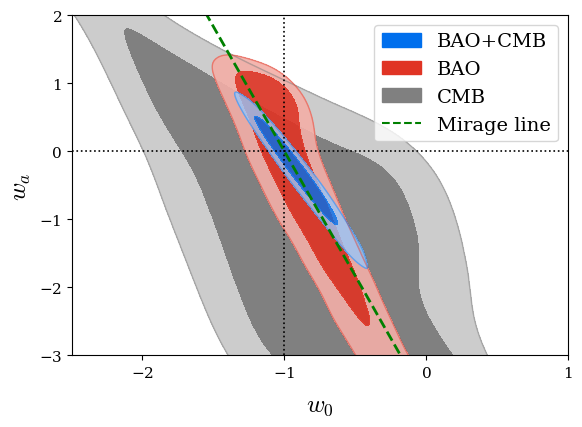

In [29]:
sample_toplot = [sample_onlyCMB, sample_onlyBAO_LCDM if fake_LCDM else sample_onlyBAO, 
                 tot_sample_fake if fake_LCDM else tot_sample_DESI]
label_toplot = ['CMB', 'BAO', 'BAO+CMB']
gdplot = gdplt.get_single_plotter()

gdplot.settings.axes_labelsize = 18
gdplot.plot_2d(sample_toplot, varNames[2], varNames[3], filled=True, contour_lws=2, alphas=[1, 0.9, 0.8])

ax = plt.gca()
x_line = np.linspace(-3, 1, 10)
y_line = -3.66 * (x_line + 1)
ax.plot(x_line, y_line, ls='--', color='g', lw=2)

ax.set_xlim(-2.5, 1)
ax.set_ylim(-3, 2)
ax.axhline(0, ls=':', color='k', lw=1.2)
ax.axvline(-1, ls=':', color='k', lw=1.2)

colors = gdplot.settings.solid_colors

legend_handles = []
n = len(sample_toplot)
for i in range(n):
    legend_handles.append(mpatches.Patch(color=colors[i], label=label_toplot[n-i-1]))

legend_handles.append(mlines.Line2D([], [], color='g', ls='--', label='Mirage line'))
ax.legend(handles=legend_handles, loc='upper right')

if Save_fig: 
    path_to_fig = r'C:\EPFL\MA4\code\PDM2026\figures'
    if fake_LCDM:
        gdplot.export(f'CMB_BAO_constraints_LCDM_cent.pdf', path_to_fig + r'\fake_data\w_wa_individual\early_CMB', dpi=300)
    else:
        gdplot.export(f'CMB_BAO_constraints_DESI_cent.pdf', path_to_fig + r'\DESI_data\w_wa_individual\early_CMB', dpi=300)


### plot last 2 redshift together

In [90]:
save_double_fig = True

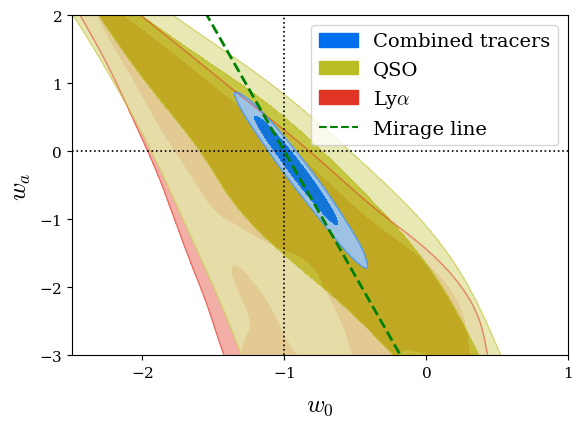

In [91]:
k, l = 5, 6
sample_toplot = [gd_sample[l], gd_sample[k], tot_sample_fake if fake_LCDM else tot_sample_DESI]
label_toplot = [labels[l], labels[k], 'Combined tracers']
gdplot = gdplt.get_single_plotter()
gdplot.settings.axes_labelsize = 18
colors = gdplot.settings.solid_colors

contour_colors = [colors[1], 'C8', colors[0]]

gdplot.plot_2d(sample_toplot, varNames[2], varNames[3], filled=True, contour_lws=2, alphas=[1, 0.85, 0.9],
               line_args=[{'color': c} for c in contour_colors])

ax = plt.gca()
x_line = np.linspace(-3, 1, 10)
y_line = -3.66 * (x_line + 1)
ax.plot(x_line, y_line, ls='--', color='g', lw=2)

ax.set_xlim(-2.5, 1)
ax.set_ylim(-3, 2)
ax.axhline(0, ls=':', color='k', lw=1.2)
ax.axvline(-1, ls=':', color='k', lw=1.2)

h1 = mpatches.Patch(color=contour_colors[2], label=label_toplot[2])
h2 = mpatches.Patch(color=contour_colors[1], label=label_toplot[1])
h3 = mpatches.Patch(color=contour_colors[0], label=label_toplot[0])
h4 = mlines.Line2D([], [], color='g', ls='--', label='Mirage line')
ax.legend(handles=[h1, h2, h3, h4], loc='upper right')

if save_double_fig:
    path_to_fig = r'C:\EPFL\MA4\code\PDM2026\figures'
    if fake_LCDM:
        gdplot.export(f'earlyCMB_z{k+1}_z{l+1}_LCDM.png', path_to_fig + r'\fake_data\w_wa_individual\early_CMB', dpi=300)
    else:
        gdplot.export(f'earlyCMB_z{k+1}_z{l+1}.png', path_to_fig + r'\DESI_data\w_wa_individual\early_CMB', dpi=300)
